In [2]:
import pandas as pd
import os

In [3]:
pwd=os.getcwd()
filepath=os.path.join(pwd,"wine.csv")

In [5]:
data_import=pd.read_csv(filepath)
data_import

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


<Axes: >

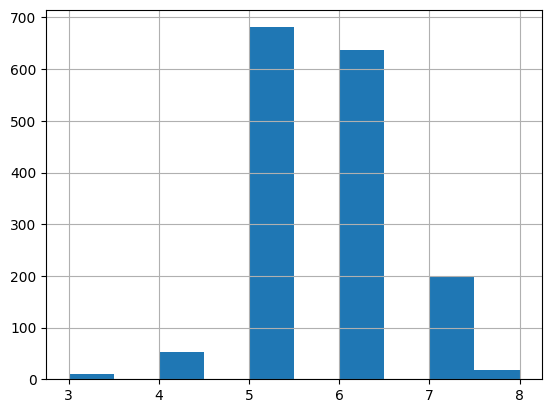

In [7]:
data_import["quality"].hist()

In [8]:
y=data_import["quality"]>5
y

0       False
1       False
2       False
3        True
4       False
        ...  
1594    False
1595     True
1596     True
1597    False
1598     True
Name: quality, Length: 1599, dtype: bool

In [10]:
#dropping the quality feature because thats what we are going to predict
X=data_import.iloc[:,:-1]
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9
...,...,...,...,...,...,...,...,...,...,...,...
1130,9.1,0.600,0.00,1.9,0.058,5.0,10.0,0.99770,3.18,0.63,10.4
1294,8.2,0.635,0.10,2.1,0.073,25.0,60.0,0.99638,3.29,0.75,10.9
860,7.2,0.620,0.06,2.7,0.077,15.0,85.0,0.99746,3.51,0.54,9.5
1459,7.9,0.200,0.35,1.7,0.054,7.0,15.0,0.99458,3.32,0.80,11.9


In [14]:
#bringing all the values to certain range meaning scaling so that model doesnt get confused
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_X_trained=scaler.fit_transform(X_train)
scaled_X_trained

array([[ 0.21833164,  0.88971201,  0.19209222, ...,  1.09349989,
         0.45822284,  1.12317723],
       [-1.29016623, -1.78878251,  0.65275338, ..., -0.40043872,
        -0.40119696,  1.40827174],
       [ 1.49475291, -0.78434707,  1.01104539, ..., -0.07566946,
         0.51551749, -0.58738978],
       ...,
       [-0.65195559,  0.49909822, -1.08752211, ...,  1.28836145,
        -0.68767023, -0.87248428],
       [-0.24582155, -1.84458448,  0.39683051, ...,  0.05423824,
         0.80199076,  1.40827174],
       [-1.46422367, -1.34236676, -0.06383064, ...,  0.50891521,
        -0.68767023,  2.92877575]], shape=(1279, 11))

In [17]:
scaled_X_test=scaler.transform(X_test)
scaled_X_test

array([[-3.61859850e-01,  1.64286407e-01, -9.85152962e-01, ...,
        -4.65392578e-01, -1.34389336e-04, -7.77452782e-01],
       [-3.03840702e-01, -1.70525408e-01, -5.24491803e-01, ...,
         5.08915214e-01, -1.03143815e+00, -8.72484283e-01],
       [ 1.37871461e+00,  7.78108067e-01, -2.68568937e-01, ...,
        -2.05577167e-01,  1.83329452e+00, -4.92358280e-01],
       ...,
       [-1.37449586e-02,  3.87494284e-01, -1.15015218e-01, ...,
        -1.04997725e+00, -7.44964886e-01, -5.87389780e-01],
       [ 2.76350785e-01, -1.45397070e+00,  6.01568807e-01, ...,
        -1.04997725e+00,  1.71749571e-01,  7.43051230e-01],
       [ 4.50408230e-01,  1.30822677e+00, -1.18989125e+00, ...,
        -1.40623314e-01, -6.87670232e-01, -6.82421281e-01]],
      shape=(320, 11))

In [18]:
def preprocessing_function(X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    scaled_X_trained=scaler.fit_transform(X_train)
    scaled_X_test=scaler.transform(X_test)
    return scaled_X_trained,scaled_X_test,y_train,y_test

In [19]:
y_train

493      True
354      True
342      True
834     False
705     False
        ...  
1130     True
1294     True
860     False
1459     True
1126     True
Name: quality, Length: 1279, dtype: bool

In [22]:
from sklearn.svm import SVC
svc_clf=SVC()
svc_clf.fit(scaled_X_trained,y_train)
SVC()

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
svc_clf_predictions=svc_clf.predict(scaled_X_test)
svc_clf_predictions

array([False, False,  True, False,  True, False, False, False,  True,
        True,  True, False,  True, False, False,  True, False,  True,
        True, False, False, False,  True,  True, False,  True,  True,
       False, False,  True, False, False,  True, False,  True, False,
        True,  True,  True,  True,  True, False,  True, False,  True,
        True,  True,  True, False,  True, False, False,  True,  True,
       False, False,  True, False,  True, False,  True,  True, False,
       False,  True, False,  True, False,  True, False,  True, False,
        True,  True,  True, False,  True,  True,  True,  True, False,
        True, False, False,  True,  True, False,  True,  True, False,
        True, False, False,  True, False,  True, False,  True, False,
        True, False, False,  True,  True,  True,  True,  True, False,
        True, False,  True, False,  True, False,  True,  True,  True,
       False, False,  True,  True,  True,  True, False, False, False,
        True,  True,

array([[109,  32],
       [ 41, 138]])

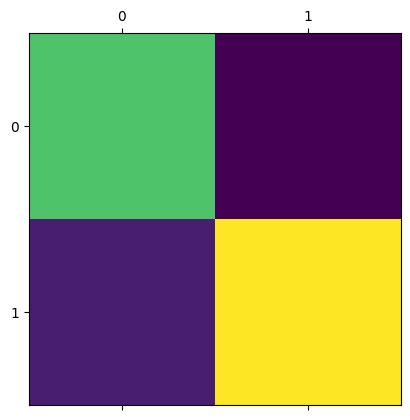

In [32]:
#fitting confusion matrix
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score
import  matplotlib.pyplot as plt
plt.matshow(confusion_matrix(y_test,svc_clf_predictions))
confusion_matrix(y_test,svc_clf_predictions)

In [27]:
accuracy_score(y_test,svc_clf_predictions)

0.771875

In [28]:
precision_score(y_test,svc_clf_predictions)


0.8117647058823529

In [29]:
recall_score(y_test,svc_clf_predictions)

0.770949720670391

In [39]:
def algo_accuracy(y_test,predictions):
    conf_matrix=confusion_matrix(y_test,predictions)
    accuracy=accuracy_score(y_test,predictions)
    precision=precision_score(y_test,predictions)
    recall=recall_score(y_test,predictions)
    return conf_matrix,accuracy,precision,recall

In [34]:
##grid search for hyper parameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid=[
    #try 12 {3*4} combinations of hyperparameters
    {'n_estimators':[3,10,30], 'max_features':[2,4,6,8]},
    #then try 6 2*3 combinations with bootstrap set as False
    {'bootstrap':[False],'n_estimators':[3,10],'max_features':[2,3,4]},    
]
rfc=RandomForestClassifier()

#train across 5 folds ,thats a total of (12+6)*5=90 rounds of training
grid_search=GridSearchCV(rfc,param_grid,cv=5,scoring='accuracy',return_train_score=True)
grid_search.fit(scaled_X_trained,y_train)


,estimator,RandomForestClassifier()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [35]:
rfc_clf=grid_search.best_estimator_
rfc_clf

,n_estimators,30
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rfc_predictions=rfc_clf.predict(scaled_X_test)
rfc_predictions

array([False, False, False, False,  True, False, False, False,  True,
        True,  True, False,  True, False, False,  True, False,  True,
        True, False, False,  True, False,  True,  True,  True,  True,
       False, False,  True, False, False,  True,  True,  True, False,
        True,  True,  True,  True, False, False,  True, False,  True,
        True,  True,  True, False, False, False, False, False,  True,
       False,  True,  True, False,  True, False,  True,  True, False,
       False,  True, False,  True,  True,  True, False,  True, False,
       False,  True,  True, False,  True, False,  True,  True, False,
        True, False,  True,  True,  True, False,  True,  True, False,
        True,  True, False, False, False, False, False,  True, False,
       False, False, False,  True,  True,  True,  True,  True, False,
        True, False,  True, False,  True, False,  True,  True, False,
       False, False,  True,  True,  True,  True, False,  True, False,
        True,  True,

In [40]:
algo_accuracy(y_test,rfc_predictions)

(array([[112,  29],
        [ 37, 142]]),
 0.79375,
 0.8304093567251462,
 0.7932960893854749)